# Testing for the 3DInt Method for Diploids, Autos, and Allos

In [1]:
import numpy as np
import dadi 
from matplotlib import pyplot as plt
import dadi.Polyploidy.Integration as PolyInt
from dadi.Polyploidy import wrightfisher as WF
import time

## Comparisons to dadi under special cases

In [2]:
# plotting function

# although handy for debugging, this is quite cumnbersome to use frequently to test
# the accuracy of the integration

# instead, we use numpy.allclose to compare the results

def phi_3D_plot(phi_poly, phi_dadi, edges, axis1, xlab, ylab, plotall=False):
    # marginalize once
    phi_dadi1 = np.sum(phi_dadi, axis=axis1)
    phi_poly1 = np.sum(phi_poly, axis=axis1)

    if plotall:
        plt.pcolormesh(edges, edges, phi_poly1.T, cmap='viridis', shading='auto')
        plt.colorbar(label='Density')
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.title('PolyInt')
        plt.show()

        plt.pcolormesh(edges, edges, phi_dadi1.T, cmap='viridis', shading='auto')
        plt.colorbar(label='Density')
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.title('dadi')
        plt.show()

        plt.pcolormesh(edges, edges, phi_poly1.T - phi_dadi1.T, cmap='viridis', shading='auto')
        plt.colorbar(label='Density')
        plt.xlabel(xlab)
        plt.ylabel(ylab)
        plt.title('PolyInt - dadi')
        plt.show()

    plt.pcolormesh(edges, edges, (phi_poly1.T - phi_dadi1.T)/phi_dadi1.T, cmap='viridis', shading='auto')
    plt.colorbar(label='Density')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title('(PolyInt - dadi)/dadi')
    plt.show()

    print(f"Max deviation between dadi and PolyInt: {np.max(np.abs(phi_poly1.T - phi_dadi1.T))}")
    

### First, we want to compare all diploids to the original dadi code

In [3]:
xx = dadi.Numerics.default_grid(pts=51)
phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=-5, h=0.5)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)

dipflag = PolyInt.PloidyType.DIPLOID
T = .1
gamma1 = -5
gamma2 = 10
gamma3 = 2
h1 = 0.5
h2 = 0.5
h3 = 0.5
m12 = .1
m21 = .01
m31 = .2
m13 = 0
m23 = .15
m32 = .05
sel_dip1 = {'gamma': gamma1, 'h': h1}
sel_dip2 = {'gamma': gamma2, 'h': h2}
sel_dip3 = {'gamma': gamma3, 'h': h3}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu3 = 0.5
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)

phi_poly = PolyInt.three_pops(phi.copy(), xx, T=T, 
                              ploidyflag1=dipflag, ploidyflag2=dipflag, ploidyflag3=dipflag,
                              sel_dict1=sel_dip1, sel_dict2=sel_dip2, sel_dict3=sel_dip3,
                              nu1=nu1_func, nu2=nu2_func, nu3=nu3_func,
                              m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                              theta0=0)

phi_dadi = dadi.Integration.three_pops(phi.copy(), xx, T=T, theta0=0, 
                                    gamma1=gamma1, gamma2=gamma2, gamma3=gamma3,
                                    h1=h1, h2=h2, h3=h3,
                                    m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                                    nu1=nu1_func, nu2=nu2_func, nu3=nu3_func)

assert np.allclose(phi_poly, phi_dadi)

# mid = 0.5 * (xx[1:] + xx[:-1])
# first = xx[0] - (mid[0] - xx[0])
# last = xx[-1] + (xx[-1] - mid[-1])
# edges = np.concatenate([[first], mid, [last]])

# phi_3D_plot(phi_poly, phi_dadi, edges, 0, 'Pop 2', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 1, 'Pop 1', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 2, 'Pop 1', 'Pop 2')  

### Second, we can test a diploid and two allotetraploid subgenomes without selection and compare to dadi

In [4]:
xx = dadi.Numerics.default_grid(pts=101)
phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=0, h=0.5)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)

dipflag = PolyInt.PloidyType.DIPLOID
alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .01
gamma1 = -5
gamma2 = 0
gamma3 = 0
gamma_allo = 0
h1 = 0.5
h2 = 0.5
h3 = 0.5
m12 = .1
m21 = .01
m31 = .2
m13 = 0
m23 = 0.1
m32 = 0.1
sel_dip = {'gamma': gamma1, 'h': h1}
sel_allo = {'gamma': gamma_allo}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu3 = 3.0
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)

phi_poly = PolyInt.three_pops(phi.copy(), xx, T=T, 
                              ploidyflag1=dipflag, ploidyflag2=alloaflag, ploidyflag3=allobflag,
                              sel_dict1=sel_dip, sel_dict2=sel_allo, sel_dict3=sel_allo,
                              nu1=nu1_func, nu2=nu2_func, nu3=nu3_func,
                              m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                              theta0=0)

phi_dadi = dadi.Integration.three_pops(phi.copy(), xx, T=T, theta0=0, 
                                    gamma1=gamma1, gamma2=gamma2, gamma3=gamma3,
                                    h1=h1, h2=h2, h3=h3,
                                    m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                                    nu1=nu1_func, nu2=nu2_func, nu3=nu3_func)

assert np.allclose(phi_poly, phi_dadi)

# mid = 0.5 * (xx[1:] + xx[:-1])
# first = xx[0] - (mid[0] - xx[0])
# last = xx[-1] + (xx[-1] - mid[-1])
# edges = np.concatenate([[first], mid, [last]])

# phi_3D_plot(phi_poly, phi_dadi, edges, 0, 'Pop 2', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 1, 'Pop 1', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 2, 'Pop 1', 'Pop 2')

### Third, we can compare all autotetraploids with double the time, halved the migration, and equal selection to dadi

In [5]:
xx = dadi.Numerics.default_grid(pts=21)
phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=0, h=0.5)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)

autoflag = PolyInt.PloidyType.AUTO
T = 1
gamma1 = -2
gamma2 = 5
gamma3 = -10
h1 = 0.5
h2 = 0.5
h3 = 0.5
m12 = 0
m21 = 0
m31 = 0
m13 = 0
m23 = 0
m32 = 0
sel_auto1 = {'gamma': gamma1}
sel_auto2 = {'gamma': gamma2}
sel_auto3 = {'gamma': gamma3}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu1_func_auto = lambda t: np.exp(np.log(nu1)*t/(2*T))
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu2_func_auto = lambda t: np.exp(np.log(nu2)*t/(2*T))
nu3 = 3.0
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)
nu3_func_auto = lambda t: np.exp(np.log(nu3)*t/(2*T))

phi_poly = PolyInt.three_pops(phi.copy(), xx, T=2*T, 
                              ploidyflag1=autoflag, ploidyflag2=autoflag, ploidyflag3=autoflag,
                              sel_dict1=sel_auto1, sel_dict2=sel_auto2, sel_dict3=sel_auto3,
                              nu1=nu1_func_auto, nu2=nu2_func_auto, nu3=nu3_func_auto,
                              m12=m12/2, m21=m21/2, m13=m13/2, m31=m31/2, m23=m23/2, m32=m32/2,
                              theta0=0)

phi_dadi = dadi.Integration.three_pops(phi.copy(), xx, T=T, theta0=0, 
                                    gamma1=gamma1, gamma2=gamma2, gamma3=gamma3,
                                    h1=h1, h2=h2, h3=h3,
                                    m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                                    nu1=nu1_func, nu2=nu2_func, nu3=nu3_func)

assert np.allclose(phi_poly, phi_dadi)  

# mid = 0.5 * (xx[1:] + xx[:-1])
# first = xx[0] - (mid[0] - xx[0])
# last = xx[-1] + (xx[-1] - mid[-1])
# edges = np.concatenate([[first], mid, [last]])

# phi_3D_plot(phi_poly, phi_dadi, edges, 0, 'Pop 2', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 1, 'Pop 1', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 2, 'Pop 1', 'Pop 2')

### Fourth, we can compare to alloallohexaploids (2+2+2) without selection to all diploids in dadi

In [11]:
xx = dadi.Numerics.default_grid(pts=71)
phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=0, h=0.5)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)

hexaflag = PolyInt.PloidyType.HEXa
hexbflag = PolyInt.PloidyType.HEXb
hexcflag = PolyInt.PloidyType.HEXc
T = .01
gamma1 = 0
gamma2 = 0
gamma3 = 0
gamma_hex = 0
h1 = 0.5
h2 = 0.5
h3 = 0.5
m12 = 2
m21 = 2
m31 = .2
m13 = .2
m23 = .1
m32 = .1
sel_dip = {'gamma': gamma1, 'h': h1}
sel_hex = {'gamma': gamma_hex}
nu1 = 3.0
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu3 = 3.0
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)

phi_poly = PolyInt.three_pops(phi.copy(), xx, T=T, 
                              ploidyflag1=hexaflag, ploidyflag2=hexbflag, ploidyflag3=hexcflag,
                              sel_dict1=sel_hex, sel_dict2=sel_hex, sel_dict3=sel_hex,
                              nu1=nu1_func, nu2=nu2_func, nu3=nu3_func,
                              m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                              theta0=0)

phi_dadi = dadi.Integration.three_pops(phi.copy(), xx, T=T, theta0=0, 
                                    gamma1=gamma1, gamma2=gamma2, gamma3=gamma3,
                                    h1=h1, h2=h2, h3=h3,
                                    m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                                    nu1=nu1_func, nu2=nu2_func, nu3=nu3_func)

assert np.allclose(phi_poly, phi_dadi)

# mid = 0.5 * (xx[1:] + xx[:-1])
# first = xx[0] - (mid[0] - xx[0])
# last = xx[-1] + (xx[-1] - mid[-1])
# edges = np.concatenate([[first], mid, [last]])

# phi_3D_plot(phi_poly, phi_dadi, edges, 2, 'Pop 1', 'Pop 2')
# phi_3D_plot(phi_poly, phi_dadi, edges, 1, 'Pop 1', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 0, 'Pop 2', 'Pop 3')


### Finally, we can test all autohexaploids to diploids with tripled time, = selection, and 1/3 migration

In [12]:
xx = dadi.Numerics.default_grid(pts=71)
phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=0, h=0.5)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)

hexflag = PolyInt.PloidyType.AUTOHEX
T = .1
gamma1 = -2
gamma2 = 5
gamma3 = -10
h1 = 0.5
h2 = 0.5
h3 = 0.5
m12 = 0
m21 = 0
m31 = 0
m13 = 0
m23 = 0
m32 = 0
sel_auto1 = {'gamma': gamma1}
sel_auto2 = {'gamma': gamma2}
sel_auto3 = {'gamma': gamma3}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu1_func_auto = lambda t: np.exp(np.log(nu1)*t/(3*T))
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu2_func_auto = lambda t: np.exp(np.log(nu2)*t/(3*T))
nu3 = 3.0
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)
nu3_func_auto = lambda t: np.exp(np.log(nu3)*t/(3*T))

phi_poly = PolyInt.three_pops(phi.copy(), xx, T=3*T, 
                              ploidyflag1=hexflag, ploidyflag2=hexflag, ploidyflag3=hexflag,
                              sel_dict1=sel_auto1, sel_dict2=sel_auto2, sel_dict3=sel_auto3,
                              nu1=nu1_func_auto, nu2=nu2_func_auto, nu3=nu3_func_auto,
                              m12=m12/3, m21=m21/3, m13=m13/3, m31=m31/3, m23=m23/3, m32=m32/3,
                              theta0=0)

phi_dadi = dadi.Integration.three_pops(phi.copy(), xx, T=T, theta0=0, 
                                    gamma1=gamma1, gamma2=gamma2, gamma3=gamma3,
                                    h1=h1, h2=h2, h3=h3,
                                    m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                                    nu1=nu1_func, nu2=nu2_func, nu3=nu3_func)

assert np.allclose(phi_poly, phi_dadi)  

# mid = 0.5 * (xx[1:] + xx[:-1])
# first = xx[0] - (mid[0] - xx[0])
# last = xx[-1] + (xx[-1] - mid[-1])
# edges = np.concatenate([[first], mid, [last]])

# phi_3D_plot(phi_poly, phi_dadi, edges, 0, 'Pop 2', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 1, 'Pop 1', 'Pop 3')
# phi_3D_plot(phi_poly, phi_dadi, edges, 2, 'Pop 1', 'Pop 2')

### 4+2 Hexaploid model
Note that we cannot compare to dadi, but we use this for valdiating the GPU code

In [ ]:
xx = dadi.Numerics.default_grid(pts=71)
phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=0, h=0.5)
phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)

dipflag = PolyInt.PloidyType.DIPLOID
hextetraflag = PolyInt.PloidyType.HEX_tetra
hexdipflag = PolyInt.PloidyType.HEX_dip

T = .1
gamma1 = -2
gamma2 = 5
gamma3 = 5
h1 = 0.5
h2 = 0.5
h3 = 0.5
m12 = .3
m21 = .2
m31 = .4
m13 = .05
m23 = m32 = .3
sel_auto1 = {'gamma': gamma1}
sel_auto2 = {'gamma': gamma2}
sel_auto3 = {'gamma': gamma3}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu3 = 3.0
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)

phi_poly = PolyInt.three_pops(phi.copy(), xx, T=T, 
                              ploidyflag1=dipflag, ploidyflag2=hextetraflag, ploidyflag3=hexdipflag,
                              sel_dict1=sel_auto1, sel_dict2=sel_auto2, sel_dict3=sel_auto3,
                              nu1=nu1_func_auto, nu2=nu2_func_auto, nu3=nu3_func_auto,
                              m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                              theta0=0)

## Comparisons to WF Simulations

### Allotetraploid + Diploid WF

In [16]:
# xx = dadi.Numerics.default_grid(pts=101)
# phi = dadi.PhiManip.phi_1D(xx, theta0=1, gamma=0, h=0.5)
# phi = dadi.PhiManip.phi_1D_to_2D(xx, phi)
# phi = dadi.PhiManip.phi_2D_to_3D(phi, 0.5, xx, xx, xx)
pts = 81
replicates = 1000000
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size, xx.size])
i, j, k = 40, 25, 55
phi[i, j, k] = replicates

dipflag = PolyInt.PloidyType.DIPLOID
alloaflag = PolyInt.PloidyType.ALLOa
allobflag = PolyInt.PloidyType.ALLOb
T = .05
gamma1 = -4
gamma_allo = -6
h1 = 0.5
m12 = 0.2
m21 = 3
m31 = .15
m13 = 0
m23 = .25
m32 = .25
sel_dip = {'gamma': gamma1, 'h': h1}
sel_allo = {'gamma': gamma_allo}
nu1 = 1.5
nu1_func = lambda t: np.exp(np.log(nu1)*t/T)
nu2 = 3.0
nu2_func = lambda t: np.exp(np.log(nu2)*t/T)
nu3 = 3.0
nu3_func = lambda t: np.exp(np.log(nu3)*t/T)

sel_dip_vec = dipflag.pack_sel_params(sel_dip)
sel_allo_vec = alloaflag.pack_sel_params(sel_allo)

phi = PolyInt.three_pops(phi.copy(), xx, T=T, 
                         ploidyflag1=dipflag, ploidyflag2=alloaflag, ploidyflag3=allobflag,
                         sel_dict1=sel_dip, sel_dict2=sel_allo, sel_dict3=sel_allo,
                         nu1=nu1_func, nu2=nu2_func, nu3=nu3_func,
                         m12=m12, m21=m21, m13=m13, m31=m31, m23=m23, m32=m32,
                         theta0=0)


wf_sim = WF.dip_allo_WF(N=2000, T=T, M12=m12, M21=m21, M13=m13, M31=m31, M23=m23, M32=m32,
                        sel1=sel_dip_vec, sel2=sel_allo_vec, sel3=sel_allo_vec,
                        init_q1=np.full(replicates,xx[i]), init_q2=np.full(replicates,xx[j]), init_q3=np.full(replicates,xx[k]),
                        nu1=nu1_func, nu2=nu2_func, nu3=nu3_func,
                        replicates=replicates)

# separate diploid and allo freqs
wf_dip = wf_sim[0, :]
wf_alloa = wf_sim[1, :]
wf_allob = wf_sim[2, :]

wf_dip = WF.mask(wf_dip)
wf_alloa = WF.mask(wf_alloa)
wf_allob = WF.mask(wf_allob)

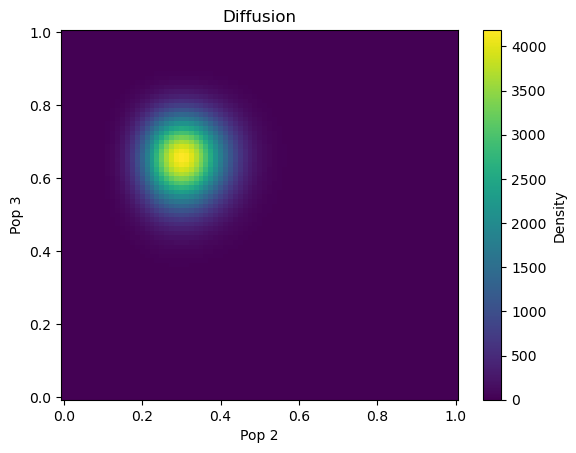

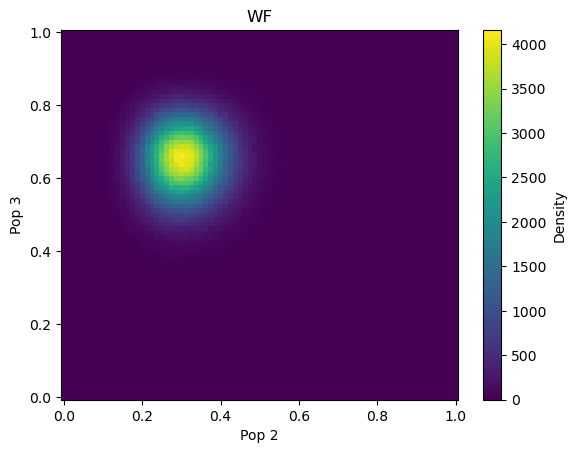

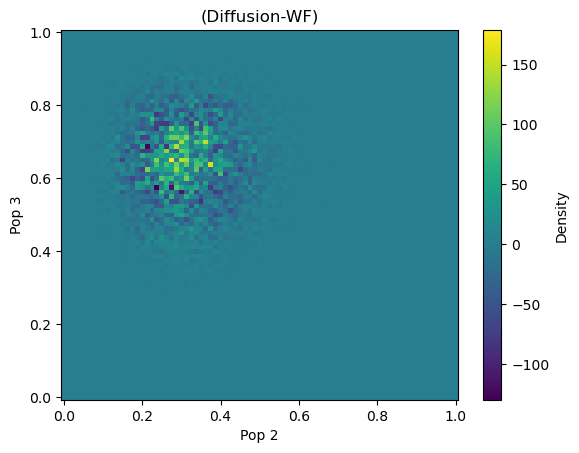

In [17]:
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

# marginalize over the first dimension
phi_1 = np.sum(phi, axis=0)

plt.pcolormesh(edges, edges, phi_1.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 2')
plt.ylabel('Pop 3')
plt.title('Diffusion')
plt.show()

hist, xedges, yedges = np.histogram2d(x=wf_alloa.flatten(), y=wf_allob.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.pcolormesh(edges, edges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 2')
plt.ylabel('Pop 3')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi_1.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 2')
plt.ylabel('Pop 3')
plt.title('(Diffusion-WF)')
plt.show()

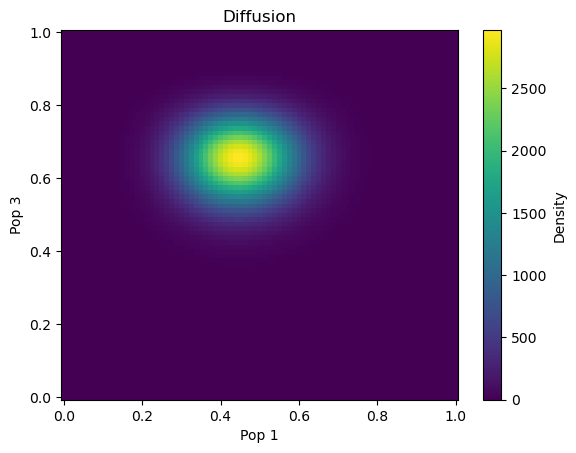

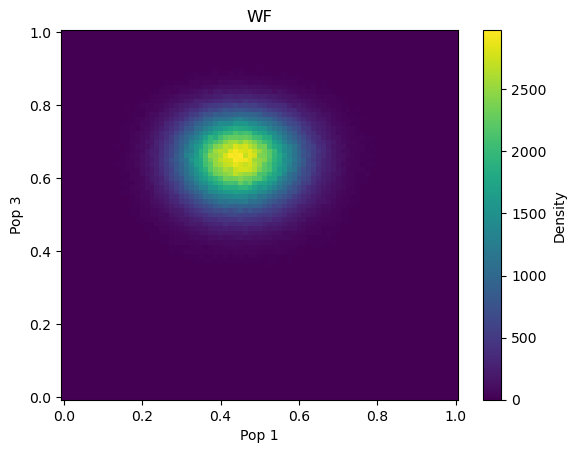

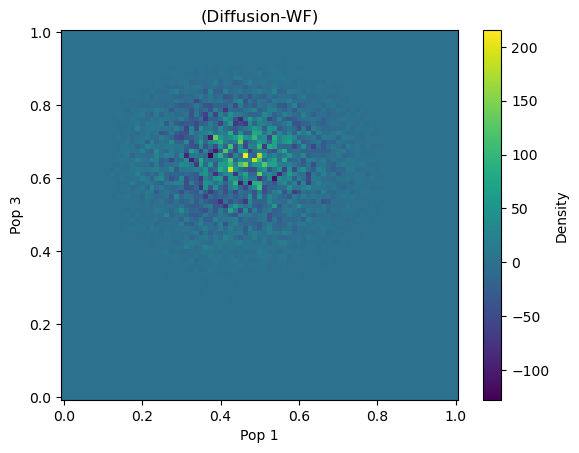

In [18]:
# marginalize over the second dimension
phi_2 = np.sum(phi, axis=1)

plt.pcolormesh(edges, edges, phi_2.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 3')
plt.title('Diffusion')
plt.show()

hist, xedges, yedges = np.histogram2d(x=wf_dip.flatten(), y=wf_allob.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.pcolormesh(edges, edges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 3')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi_2.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 3')
plt.title('(Diffusion-WF)')
plt.show()

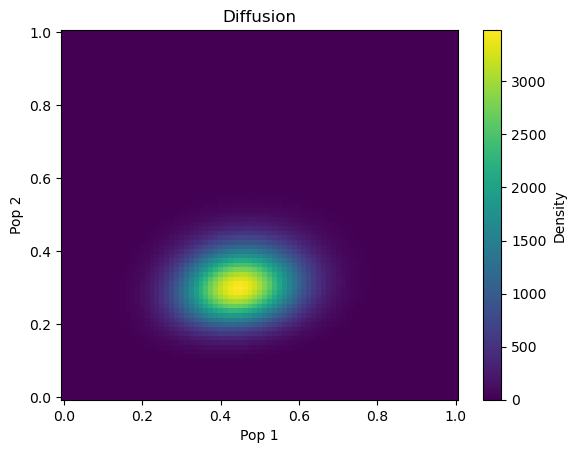

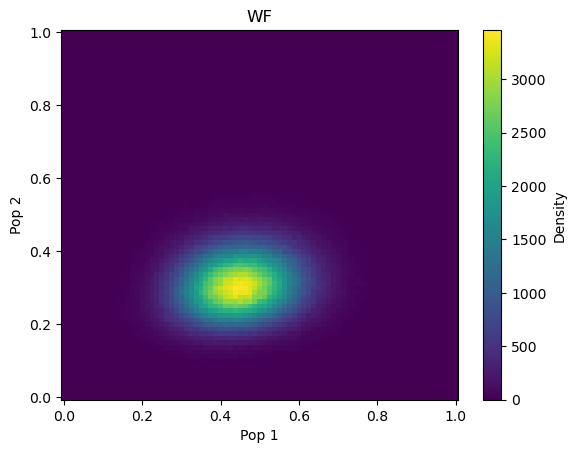

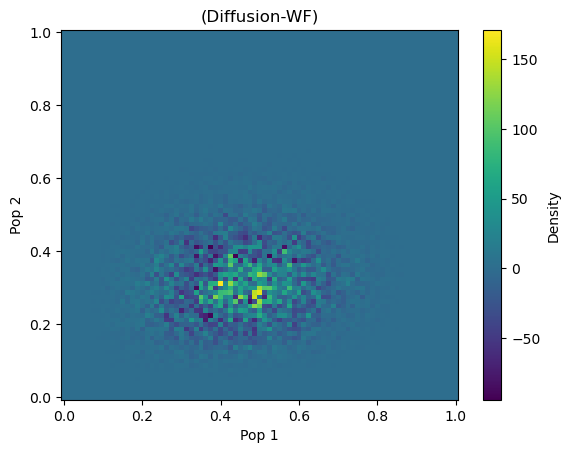

In [19]:
# marginalize over the second dimension
phi_3 = np.sum(phi, axis=2)

plt.pcolormesh(edges, edges, phi_3.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('Diffusion')
plt.show()

hist, xedges, yedges = np.histogram2d(x=wf_dip.flatten(), y=wf_alloa.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.pcolormesh(edges, edges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi_3.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('(Diffusion-WF)')
plt.show()

Mean: 0.4496249701804052
Variance: 0.009800405423175451


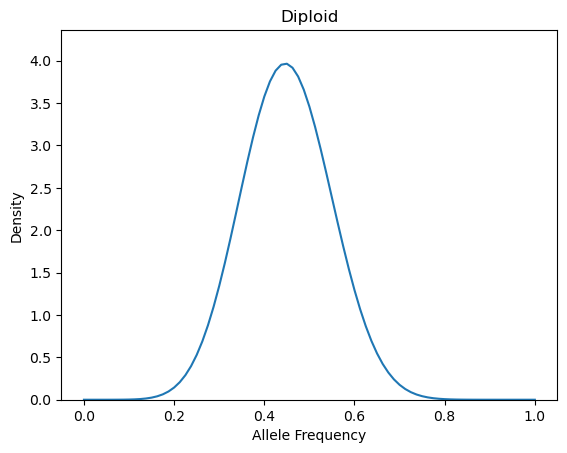

WF MODEL
Diploids Results Summary
Mean final allele frequency: 0.4495682468682144
Variance of final allele frequency: 0.009831757305149716


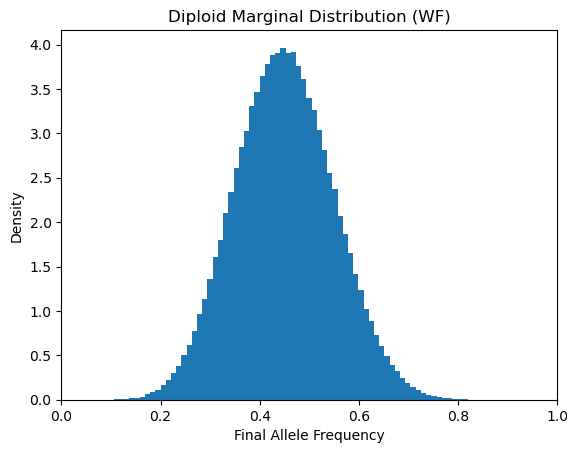

In [20]:
phi_dip = np.sum(phi, axis=2)
phi_dip = np.sum(phi_dip, axis=1)

WF.summarize_phi(phi_dip, xx, 'Diploid')

print("WF MODEL")
print("Diploids Results Summary")
print(f"Mean final allele frequency: {np.mean(wf_dip)}")
print(f"Variance of final allele frequency: {np.var(wf_dip)}")
# Plot histogram of final allele frequencies
plt.hist(wf_dip, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Diploid Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

Mean: 0.30969401813373976
Variance: 0.005044648157983528


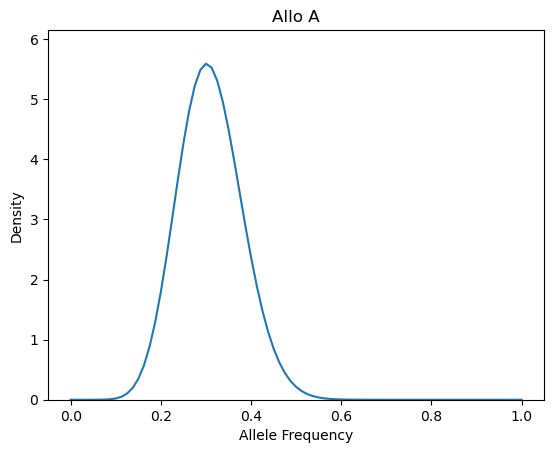

WF MODEL
Allo Subgenome A Results Summary
Mean final allele frequency: 0.30978845525389626
Variance of final allele frequency: 0.00510287624142064


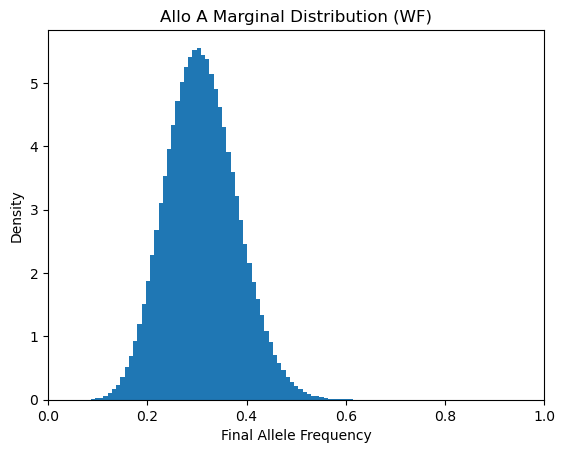

In [21]:
phi_alloa = np.sum(phi, axis=2)
phi_alloa = np.sum(phi_alloa, axis=0)

WF.summarize_phi(phi_alloa, xx, 'Allo A')

print("WF MODEL")
print("Allo Subgenome A Results Summary")
print(f"Mean final allele frequency: {np.mean(wf_alloa)}")
print(f"Variance of final allele frequency: {np.var(wf_alloa)}")
# Plot histogram of final allele frequencies
plt.hist(wf_alloa, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Allo A Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()


Mean: 0.6489515162588886
Variance: 0.00679167486048482


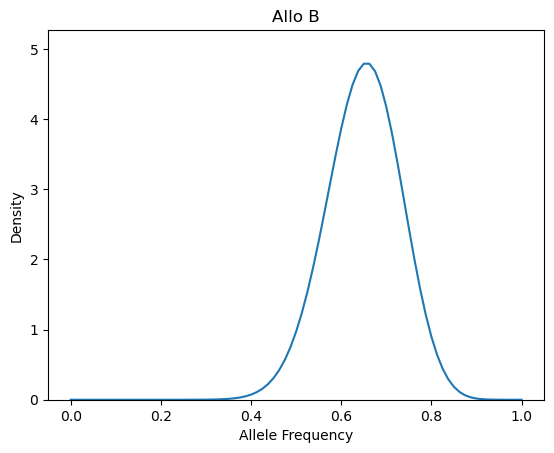

WF MODEL
Allo Subgenome A Results Summary
Mean final allele frequency: 0.6490293780794368
Variance of final allele frequency: 0.006820920317124514


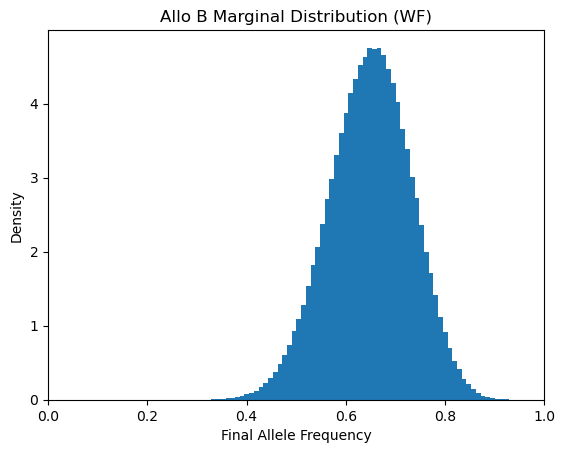

In [ ]:
phi_allob = np.sum(phi, axis=1)
phi_allob = np.sum(phi_allob, axis=0)

WF.summarize_phi(phi_allob, xx, 'Allo B')

print("WF MODEL")
print("Allo Subgenome B Results Summary")
print(f"Mean final allele frequency: {np.mean(wf_allob)}")
print(f"Variance of final allele frequency: {np.var(wf_allob)}")
# Plot histogram of final allele frequencies
plt.hist(wf_allob, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Allo B Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()


### Alloallohexaploid (2+2+2) WF

In [5]:
pts = 81
replicates = 1000000
xx = np.linspace(0, 1, pts)
phi = np.zeros([xx.size, xx.size, xx.size])
i, j, k = 40, 25, 55
phi[i, j, k] = replicates

hexaflag = PolyInt.PloidyType.HEXa
hexbflag = PolyInt.PloidyType.HEXb
hexcflag = PolyInt.PloidyType.HEXc
T = .1
gamma = -10
Eab = m12 = m21 = 0.1
Eac = m31 = m13 = .5
Ebc = m23 = m32 = 2
sel = {'gamma': gamma}
nu = 2.2
nu_func = lambda t: np.exp(np.log(nu)*t/T)

sel_v = hexaflag.pack_sel_params(sel)

phi = PolyInt.three_pops(phi.copy(), xx, T=T, ploidyflag1=hexaflag, ploidyflag2=hexbflag, ploidyflag3=hexcflag,
                                   sel_dict1=sel, sel_dict2=sel, sel_dict3=sel,
                                   nu1=nu_func, nu2=nu_func, nu3=nu_func,
                                   m12=m12, m13=m13, m21=m21, m23=m23, m31=m31, m32=m32,
                                   theta0=0)

wf_alleles = WF.hex_2_2_2_WF(N=2000, T=T, Eab=Eab, Eac=Eac, Ebc=Ebc, 
                           init_qa=np.full(replicates, xx[i]), init_qb=np.full(replicates, xx[j]), init_qc=np.full(replicates, xx[k]),
                           s = sel_v, nu = nu_func, replicates=replicates)

wf_a = wf_alleles[0,:]
wf_b = wf_alleles[1,:]
wf_c = wf_alleles[2,:]

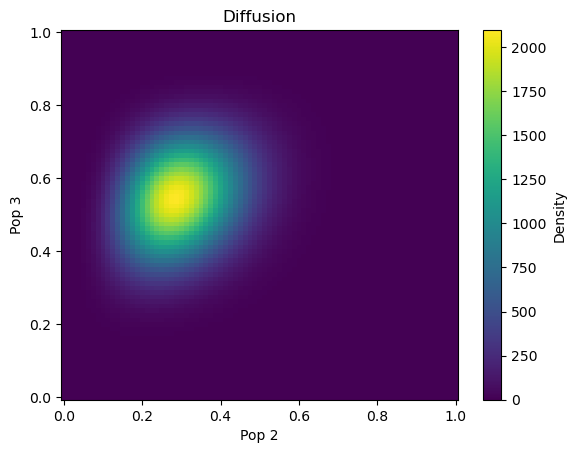

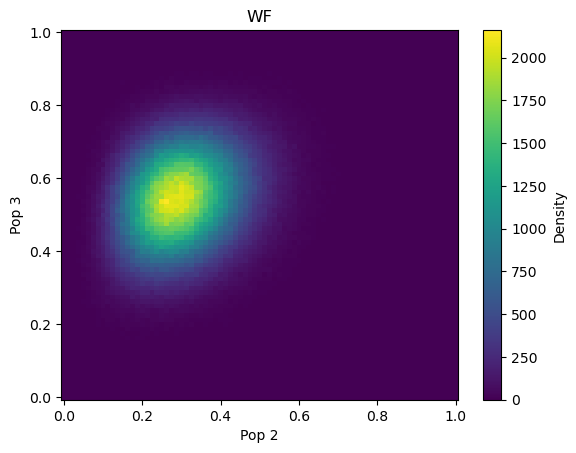

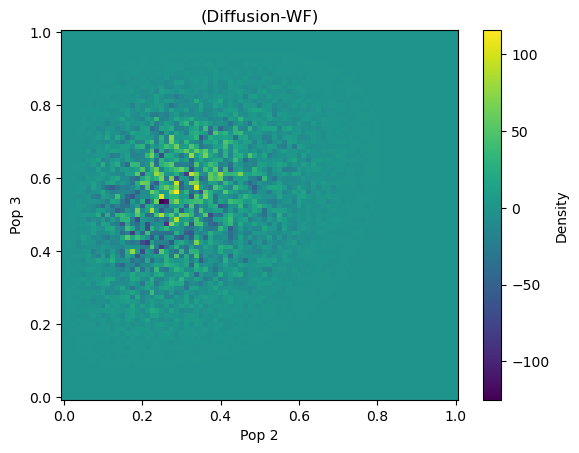

In [6]:
mid = 0.5 * (xx[1:] + xx[:-1])
first = xx[0] - (mid[0] - xx[0])
last = xx[-1] + (xx[-1] - mid[-1])
edges = np.concatenate([[first], mid, [last]])

# marginalize over the first dimension
phi_1 = np.sum(phi, axis=0)

plt.pcolormesh(edges, edges, phi_1.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 2')
plt.ylabel('Pop 3')
plt.title('Diffusion')
plt.show()

hist, xedges, yedges = np.histogram2d(x=wf_b.flatten(), y=wf_c.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.pcolormesh(edges, edges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 2')
plt.ylabel('Pop 3')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi_1.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 2')
plt.ylabel('Pop 3')
plt.title('(Diffusion-WF)')
plt.show()

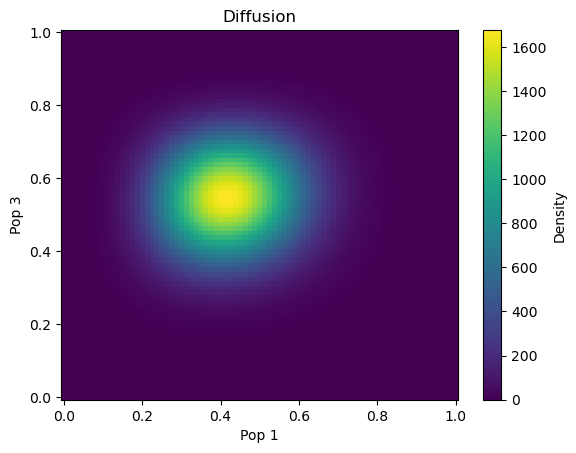

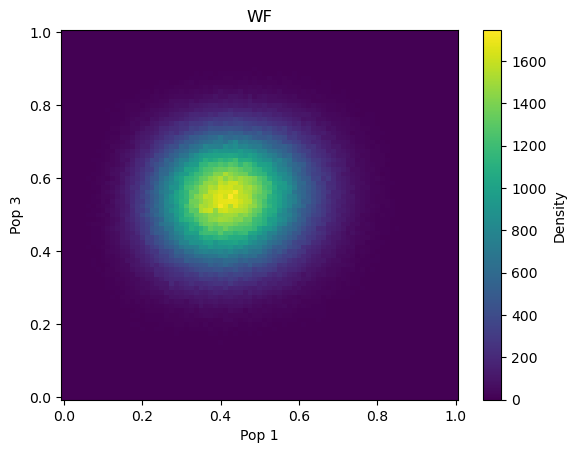

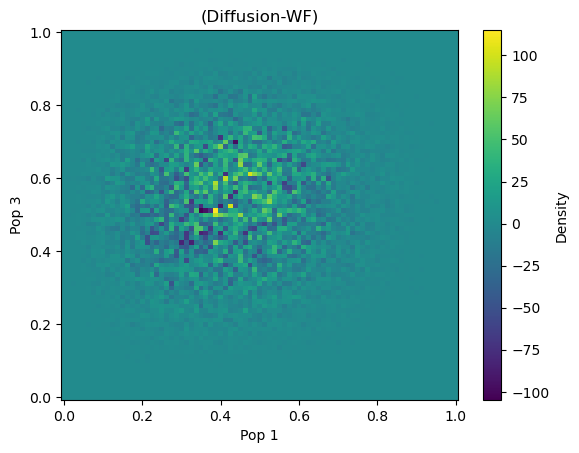

In [7]:
# marginalize over the second dimension
phi_2 = np.sum(phi, axis=1)

plt.pcolormesh(edges, edges, phi_2.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 3')
plt.title('Diffusion')
plt.show()

hist, xedges, yedges = np.histogram2d(x=wf_a.flatten(), y=wf_c.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.pcolormesh(edges, edges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 3')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi_2.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 3')
plt.title('(Diffusion-WF)')
plt.show()

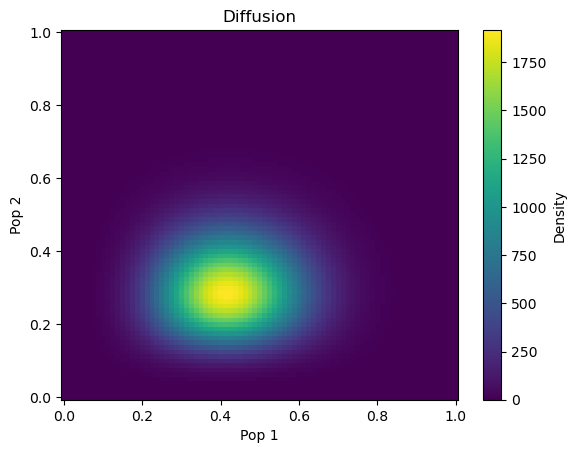

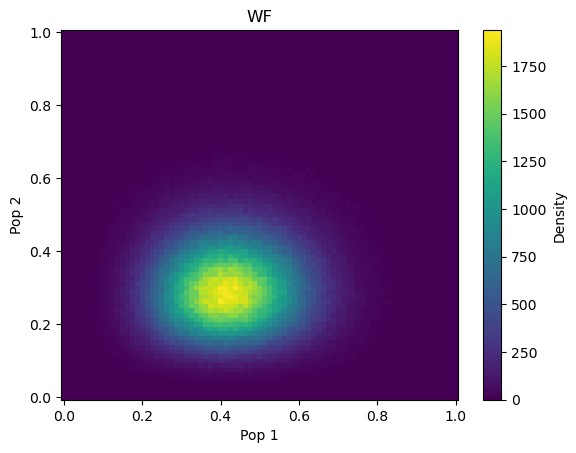

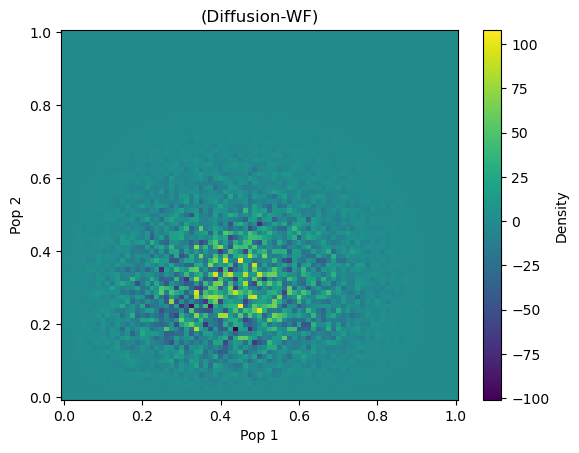

In [8]:
# marginalize over the second dimension
phi_3 = np.sum(phi, axis=2)

plt.pcolormesh(edges, edges, phi_3.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('Diffusion')
plt.show()

hist, xedges, yedges = np.histogram2d(x=wf_a.flatten(), y=wf_b.flatten(), bins=[edges, edges])

# remove lost or fixed alleles
hist[0, 0] = 0
hist[-1, -1] = 0

# Transpose due to row/column orientation
plt.pcolormesh(edges, edges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('WF')
plt.show()

plt.pcolormesh(edges, edges, (phi_3.T - hist.T), cmap='viridis', shading='auto')
plt.colorbar(label='Density')
plt.xlabel('Pop 1')
plt.ylabel('Pop 2')
plt.title('(Diffusion-WF)')
plt.show()

Mean: 0.42633766299961035
Variance: 0.015057535222730956


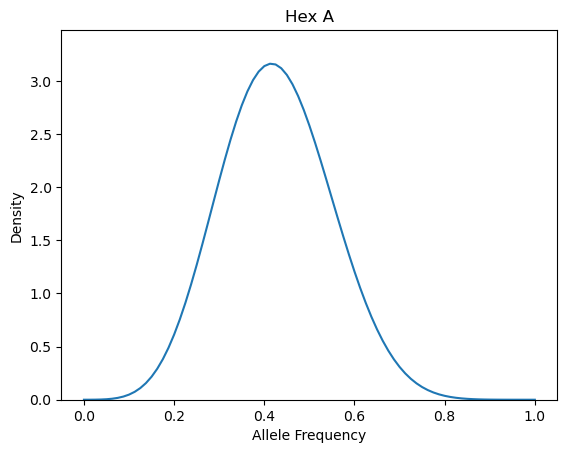

WF MODEL
Hex Subgenome A Results Summary
Mean final allele frequency: 0.4261379930539741
Variance of final allele frequency: 0.015154052020946806


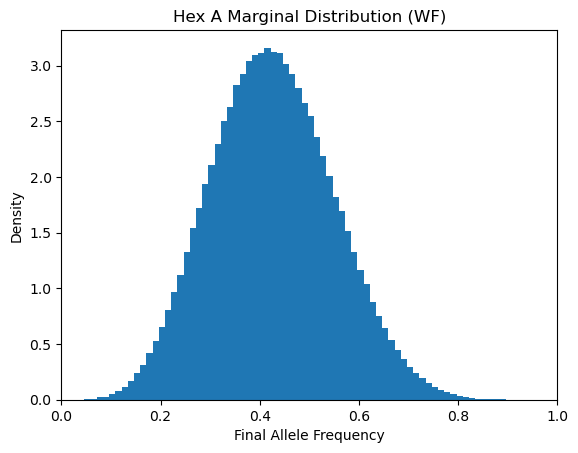

In [10]:
phi_alloa = np.sum(phi, axis=2)
phi_alloa = np.sum(phi_alloa, axis=1)

WF.summarize_phi(phi_alloa, xx, 'Hex A')

print("WF MODEL")
print("Hex Subgenome A Results Summary")
print(f"Mean final allele frequency: {np.mean(wf_a)}")
print(f"Variance of final allele frequency: {np.var(wf_a)}")
# Plot histogram of final allele frequencies
plt.hist(wf_a, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Hex A Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

Mean: 0.3054230055068684
Variance: 0.010371498281353975


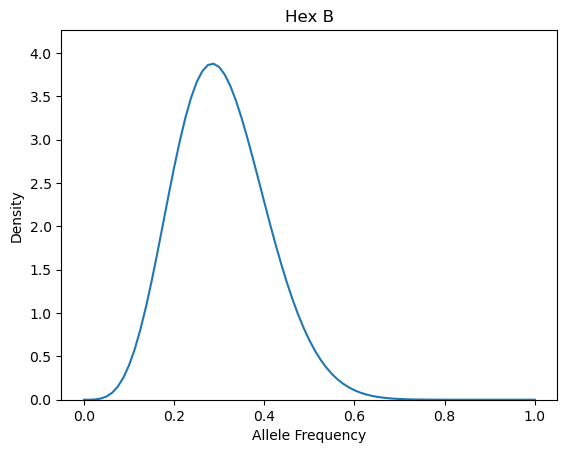

WF MODEL
Hex Subgenome B Results Summary
Mean final allele frequency: 0.3052669767706675
Variance of final allele frequency: 0.010437408345966294


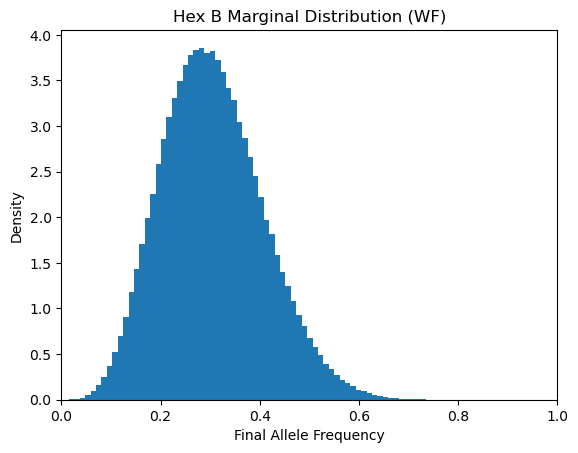

In [11]:
phi_allob = np.sum(phi, axis=2)
phi_allob = np.sum(phi_allob, axis=0)

WF.summarize_phi(phi_allob, xx, 'Hex B')

print("WF MODEL")
print("Hex Subgenome B Results Summary")
print(f"Mean final allele frequency: {np.mean(wf_b)}")
print(f"Variance of final allele frequency: {np.var(wf_b)}")
# Plot histogram of final allele frequencies
plt.hist(wf_b, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Hex B Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()

Mean: 0.5436584341094131
Variance: 0.013077936520027977


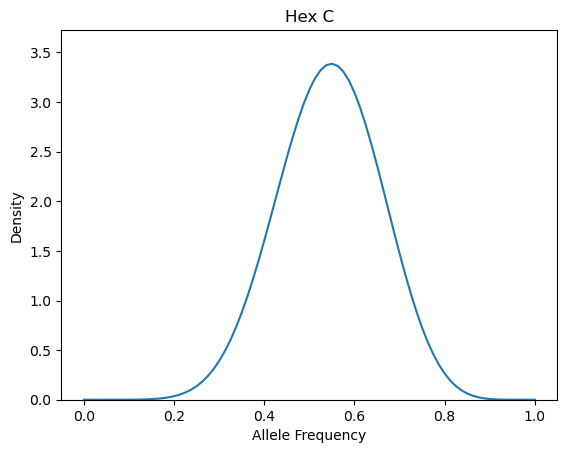

WF MODEL
Hex Subgenome C Results Summary
Mean final allele frequency: 0.5434149535413344
Variance of final allele frequency: 0.013073568713303407


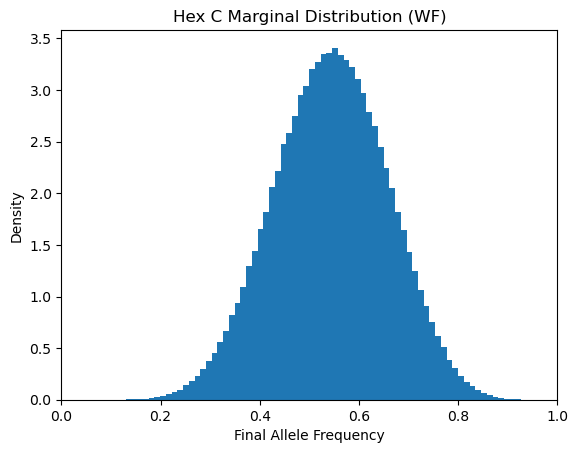

In [12]:
phi_alloc = np.sum(phi, axis=1)
phi_alloc = np.sum(phi_alloc, axis=0)

WF.summarize_phi(phi_alloc, xx, 'Hex C')

print("WF MODEL")
print("Hex Subgenome C Results Summary")
print(f"Mean final allele frequency: {np.mean(wf_c)}")
print(f"Variance of final allele frequency: {np.var(wf_c)}")
# Plot histogram of final allele frequencies
plt.hist(wf_c, bins = 75, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Hex C Marginal Distribution (WF)')
plt.xlim(0, 1)
plt.show()